In [ ]:
!python --version

Python 3.12.11


In [ ]:
import pandas as pd

def calculate_cost(row):
    model = row['model']
    prompt_tokens = row['promptTokens']
    completion_tokens = row['completionTokens']

    if model in pricing:
        input_cost = pricing[model]['input_cost_per_token']
        output_cost = pricing[model]['output_cost_per_token']
        total_cost = (prompt_tokens * input_cost) + (completion_tokens * output_cost)
        return total_cost
    else:
        return 0.0

# Manually populate with current OpenAI pricing as of 2025-09-04 (example values, replace with actual)
# Note: OpenAI typically prices per 1 million tokens.
# These values are converted to cost per single token for direct multiplication.
# 1M tokens = 1,000,000 tokens

# Example: If input cost is $15.00 / 1M tokens, cost per token = $15.00 / 1,000,000 = $0.000015
# Example: If output cost is $60.00 / 1M tokens, cost per token = $60.00 / 1,000,000 = $0.000060

pricing = {
    'gpt-5': {
        'input_cost_per_token': 1.25 / 1_000_000,  # User provided input cost per 1M tokens
        'output_cost_per_token': 10.00 / 1_000_000 # User provided output cost per 1M tokens
    },
    'gpt-5-mini': {
        'input_cost_per_token': 0.25 / 1_000_000,  # User provided input cost per 1M tokens
        'output_cost_per_token': 2.00 / 1_000_000 # User provided output cost per 1M tokens
    },
    'gpt-5-nano': {
        'input_cost_per_token': 0.05 / 1_000_000,  # User provided input cost per 1M tokens
        'output_cost_per_token': 0.40 / 1_000_000 # User provided output cost per 1M tokens
    },
    'gpt-4o': {
        'input_cost_per_token': 2.50 / 1_000_000,  # User provided input cost per 1M tokens
        'output_cost_per_token': 10.00 / 1_000_000 # User provided output cost per 1M tokens
    },
    'gpt-4o-mini': {
        'input_cost_per_token': 0.15 / 1_000_000,  # User provided input cost per 1M tokens
        'output_cost_per_token': 0.60 / 1_000_000 # User provided output cost per 1M tokens
    },
    'gemini-2.5-pro': {
        'input_cost_per_token': 1.25 / 1_000_000,  # User provided input cost per 1M tokens
        'output_cost_per_token': 10.00 / 1_000_000 # User provided output cost per 1M tokens
    },
    'gemini-2.5-flash': {
        'input_cost_per_token': 0.3 / 1_000_000,  # User provided input cost per 1M tokens
        'output_cost_per_token': 2.5 / 1_000_000 # User provided output cost per 1M tokens
    }
    # Add other models from df_tokens if they exist and have different pricing
    # 'another_model': {
    #     'input_cost_per_token': price_per_input_token_for_another_model,
    #     'output_cost_per_token': price_per_output_token_for_another_model
    # }
}

print("Pricing information:")
print(pricing)


Pricing information:
{'gpt-5': {'input_cost_per_token': 1.25e-06, 'output_cost_per_token': 1e-05}, 'gpt-5-mini': {'input_cost_per_token': 2.5e-07, 'output_cost_per_token': 2e-06}, 'gpt-5-nano': {'input_cost_per_token': 5.0000000000000004e-08, 'output_cost_per_token': 4.0000000000000003e-07}, 'gpt-4o': {'input_cost_per_token': 2.5e-06, 'output_cost_per_token': 1e-05}, 'gpt-4o-mini': {'input_cost_per_token': 1.5e-07, 'output_cost_per_token': 6e-07}, 'gemini-2.5-pro': {'input_cost_per_token': 1.25e-06, 'output_cost_per_token': 1e-05}, 'gemini-2.5-flash': {'input_cost_per_token': 3e-07, 'output_cost_per_token': 2.5e-06}}


In [ ]:
df_gpt5 = pd.read_csv("/content/langfuse_export_gpt5_250903.csv", usecols=['id', 'name', 'model', 'promptTokens', 'completionTokens', 'latency'])
df_gpt5.head()

,id,name,model,promptTokens,completionTokens,latency
0,3b8ed2c2-6784-4b0f-8e8e-7d278c14ab69,"""LLM(Images,Texts)-generation""",gpt-5,12428,10014,295.628
1,b84d31b2-9784-4155-8ed1-053d3350d8d9,LLM(Texts)-generation,gpt-5,3760,2913,82.062
2,322f941a-0e73-4f73-9dac-b46f1f998837,LLM(Images)-generation,gpt-5,8789,10277,564.263
3,e68f413b-e48c-4b78-82f2-37f0ef0e2281,"""LLM(Images,Texts)-generation""",gpt-5,7283,2575,79.380
4,add0deda-9f01-4f7e-b1e5-370b8a130d4c,LLM(Texts)-generation,gpt-5,3465,2743,77.655


In [ ]:
df_gpt4o = pd.read_csv("/content/langfuse_export_gpt_4o_250908.csv", usecols=['id', 'name', 'model', 'promptTokens', 'completionTokens', 'latency'])
df_gpt4o.head()

,id,name,model,promptTokens,completionTokens,latency
0,159f1ce3-dd1d-48d4-8eef-5a0ccfb32f5a,"""LLM(Images,Texts)-generation""",gpt-4o,13719,4260,129.337
1,e1bed19e-2293-4507-9b45-f544d7bdebbe,LLM(Texts)-generation,gpt-4o,3761,810,15.749
2,72f82565-2e4d-4eed-9d71-b0f3d344c7b7,LLM(Images)-generation,gpt-4o,10080,4240,125.936
3,679b4809-9322-4ded-844b-75c1b5f853e9,"""LLM(Images,Texts)-generation""",gpt-4o,7539,836,25.293
4,07466e20-fc39-4fad-9899-61051c0116bf,LLM(Texts)-generation,gpt-4o,3466,832,24.703


In [ ]:
df_gpt4o_mini = pd.read_csv("/content/langfuse_gpt4o_mini_250905.csv", usecols=['id', 'name', 'model', 'promptTokens', 'completionTokens', 'latency'])
df_gpt4o_mini.head()

,id,name,model,promptTokens,completionTokens,latency
0,566631c1-e858-4fbf-8a03-d6dcda525070,"""LLM(Images,Texts)-generation""",gpt-4o-mini,250087,4196,125.028
1,6d29d3f9-0725-458b-b019-e9a15aa578dc,LLM(Texts)-generation,gpt-4o-mini,3761,619,12.087
2,b3a9580f-84f5-436c-a139-bda2864cb146,LLM(Images)-generation,gpt-4o-mini,246448,4167,109.482
3,87ff043b-e2f1-467a-bd2a-c8d2f71dd338,"""LLM(Images,Texts)-generation""",gpt-4o-mini,54263,852,39.900
4,3b3da354-985e-454a-84c0-1b9970e428e1,LLM(Texts)-generation,gpt-4o-mini,3466,831,18.943


In [ ]:
df_gpt5_mini = pd.read_csv("/content/langfuse_export_gpt5_mini_250905.csv", usecols=['id', 'name', 'model', 'promptTokens', 'completionTokens', 'latency'])
df_gpt5_mini.head()

,id,name,model,promptTokens,completionTokens,latency
0,3b7d0000-4dc4-4910-8b9d-1b781503436a,"""LLM(Images,Texts)-generation""",gpt-5-mini,17018,8424,121.579
1,98931937-fc49-4a72-a48f-4518e5d372da,LLM(Texts)-generation,gpt-5-mini,3760,2315,19.148
2,3e9a0e74-fc40-44af-8035-0b8ee17e3c31,LLM(Images)-generation,gpt-5-mini,13379,8054,118.065
3,acac3176-176a-4d20-a326-e3afbae19623,"""LLM(Images,Texts)-generation""",gpt-5-mini,7876,2959,44.488
4,36d2c5ac-2c09-4897-924c-846e958dade4,LLM(Texts)-generation,gpt-5-mini,3465,2635,37.973


In [ ]:
gemini_2_5_pro = pd.read_csv("/content/langfuse_gemini_2.5_pro_export_251002.csv", usecols=['id', 'name', 'model', 'promptTokens', 'completionTokens', 'latency'])
gemini_2_5_pro.head()

,id,name,model,promptTokens,completionTokens,latency
0,f0abe2f7-151c-4200-a397-8c074a8b8968,"""LLM(Images,Texts)-generation""",gemini-2.5-pro,8353,5097,83.051
1,95125920-c312-42aa-80b4-99902c68d55f,LLM(Texts)-generation,gemini-2.5-pro,3983,856,27.360
2,c5f8fc54-31cf-41ad-bb0b-9347b6333ceb,LLM(Images)-generation,gemini-2.5-pro,4483,5114,86.508
3,bc812cd9-ff12-403f-8d69-6cb82325021e,"""LLM(Images,Texts)-generation""",gemini-2.5-pro,6740,956,24.206
4,6b17e458-9b17-4f56-bc29-d392b4639e65,LLM(Texts)-generation,gemini-2.5-pro,3680,937,33.475


In [ ]:
gemini_2_5_flash = pd.read_csv("/content/langfuse_gemini_2.5_flash_251006.csv", usecols=['id', 'name', 'model', 'promptTokens', 'completionTokens', 'latency'])
gemini_2_5_flash.head()

,id,name,model,promptTokens,completionTokens,latency
0,d1e7fa90-4d7c-4292-bc53-a7a395249336,"""LLM(Images,Texts)-generation""",gemini-2.5-flash,8353,5093,77.599
1,31786f7f-1d72-4848-9753-7e5930595dea,LLM(Texts)-generation,gemini-2.5-flash,3983,855,38.611
2,2de38958-2238-40e8-9b31-82a14722a873,LLM(Images)-generation,gemini-2.5-flash,4483,4706,79.750
3,4f2cfbb2-44f4-45b1-b4d2-c3869d7ab22d,"""LLM(Images,Texts)-generation""",gemini-2.5-flash,6740,941,19.542
4,868bd734-3559-4689-a37f-1ea687c55e24,LLM(Texts)-generation,gemini-2.5-flash,3680,937,35.156


In [ ]:
df_gpt5['cost_usd'] = df_gpt5.apply(calculate_cost, axis=1)
df_gpt5_mini['cost_usd'] = df_gpt5_mini.apply(calculate_cost, axis=1)
df_gpt4o['cost_usd'] = df_gpt4o.apply(calculate_cost, axis=1)
df_gpt4o_mini['cost_usd'] = df_gpt4o_mini.apply(calculate_cost, axis=1)
gemini_2_5_pro['cost_usd'] = gemini_2_5_pro.apply(calculate_cost, axis=1)
gemini_2_5_flash['cost_usd'] = gemini_2_5_pro.apply(calculate_cost, axis=1)

print("Cost for df_gpt5:")
display(df_gpt5.head())

print("\nCost for df_gpt5_mini:")
display(df_gpt5_mini.head())

print("\nCost for df_gpt4o:")
display(df_gpt4o.head())

print("\nCost for df_gpt4o_mini:")
display(df_gpt4o_mini.head())

print("\nCost for gemini_2_5_pro:")
display(gemini_2_5_pro.head())

print("\nCost for gemini_2_5_flash:")
display(gemini_2_5_flash.head())

Cost for df_gpt5:


,id,name,model,promptTokens,completionTokens,latency,cost_usd
0,3b8ed2c2-6784-4b0f-8e8e-7d278c14ab69,"""LLM(Images,Texts)-generation""",gpt-5,12428,10014,295.628,0.115675
1,b84d31b2-9784-4155-8ed1-053d3350d8d9,LLM(Texts)-generation,gpt-5,3760,2913,82.062,0.033830
2,322f941a-0e73-4f73-9dac-b46f1f998837,LLM(Images)-generation,gpt-5,8789,10277,564.263,0.113756
3,e68f413b-e48c-4b78-82f2-37f0ef0e2281,"""LLM(Images,Texts)-generation""",gpt-5,7283,2575,79.380,0.034854
4,add0deda-9f01-4f7e-b1e5-370b8a130d4c,LLM(Texts)-generation,gpt-5,3465,2743,77.655,0.031761



Cost for df_gpt5_mini:


,id,name,model,promptTokens,completionTokens,latency,cost_usd
0,3b7d0000-4dc4-4910-8b9d-1b781503436a,"""LLM(Images,Texts)-generation""",gpt-5-mini,17018,8424,121.579,0.021102
1,98931937-fc49-4a72-a48f-4518e5d372da,LLM(Texts)-generation,gpt-5-mini,3760,2315,19.148,0.005570
2,3e9a0e74-fc40-44af-8035-0b8ee17e3c31,LLM(Images)-generation,gpt-5-mini,13379,8054,118.065,0.019453
3,acac3176-176a-4d20-a326-e3afbae19623,"""LLM(Images,Texts)-generation""",gpt-5-mini,7876,2959,44.488,0.007887
4,36d2c5ac-2c09-4897-924c-846e958dade4,LLM(Texts)-generation,gpt-5-mini,3465,2635,37.973,0.006136



Cost for df_gpt4o:


...

,id,name,model,promptTokens,completionTokens,latency,cost_usd
0,566631c1-e858-4fbf-8a03-d6dcda525070,"""LLM(Images,Texts)-generation""",gpt-4o-mini,250087,4196,125.028,0.040031
1,6d29d3f9-0725-458b-b019-e9a15aa578dc,LLM(Texts)-generation,gpt-4o-mini,3761,619,12.087,0.000936
2,b3a9580f-84f5-436c-a139-bda2864cb146,LLM(Images)-generation,gpt-4o-mini,246448,4167,109.482,0.039467
3,87ff043b-e2f1-467a-bd2a-c8d2f71dd338,"""LLM(Images,Texts)-generation""",gpt-4o-mini,54263,852,39.900,0.008651
4,3b3da354-985e-454a-84c0-1b9970e428e1,LLM(Texts)-generation,gpt-4o-mini,3466,831,18.943,0.001018



Cost for gemini_2_5_pro:


,id,name,model,promptTokens,completionTokens,latency,cost_usd
0,f0abe2f7-151c-4200-a397-8c074a8b8968,"""LLM(Images,Texts)-generation""",gemini-2.5-pro,8353,5097,83.051,0.061411
1,95125920-c312-42aa-80b4-99902c68d55f,LLM(Texts)-generation,gemini-2.5-pro,3983,856,27.360,0.013539
2,c5f8fc54-31cf-41ad-bb0b-9347b6333ceb,LLM(Images)-generation,gemini-2.5-pro,4483,5114,86.508,0.056744
3,bc812cd9-ff12-403f-8d69-6cb82325021e,"""LLM(Images,Texts)-generation""",gemini-2.5-pro,6740,956,24.206,0.017985
4,6b17e458-9b17-4f56-bc29-d392b4639e65,LLM(Texts)-generation,gemini-2.5-pro,3680,937,33.475,0.013970



Cost for gemini_2_5_flash:


,id,name,model,promptTokens,completionTokens,latency,cost_usd
0,d1e7fa90-4d7c-4292-bc53-a7a395249336,"""LLM(Images,Texts)-generation""",gemini-2.5-flash,8353,5093,77.599,0.061411
1,31786f7f-1d72-4848-9753-7e5930595dea,LLM(Texts)-generation,gemini-2.5-flash,3983,855,38.611,0.013539
2,2de38958-2238-40e8-9b31-82a14722a873,LLM(Images)-generation,gemini-2.5-flash,4483,4706,79.750,0.056744
3,4f2cfbb2-44f4-45b1-b4d2-c3869d7ab22d,"""LLM(Images,Texts)-generation""",gemini-2.5-flash,6740,941,19.542,0.017985
4,868bd734-3559-4689-a37f-1ea687c55e24,LLM(Texts)-generation,gemini-2.5-flash,3680,937,35.156,0.013970


In [ ]:
import numpy as np

def calculate_percentile(data, percentile):
    return np.percentile(data, percentile)

print("Grouped data for df_gpt5:")
grouped_gpt5 = df_gpt5.groupby('name').agg(
    average_cost=('cost_usd', 'mean'),
    average_latency=('latency', 'mean'),
    p99_latency=('latency', lambda x: calculate_percentile(x, 99))
)
display(grouped_gpt5)

print("\nGrouped data for df_gpt5_mini:")
grouped_gpt5_mini = df_gpt5_mini.groupby('name').agg(
    average_cost=('cost_usd', 'mean'),
    average_latency=('latency', 'mean'),
    p99_latency=('latency', lambda x: calculate_percentile(x, 99))
)
display(grouped_gpt5_mini)

print("\nGrouped data for df_gpt4o:")
grouped_gpt4o = df_gpt4o.groupby('name').agg(
    average_cost=('cost_usd', 'mean'),
    average_latency=('latency', 'mean'),
    p99_latency=('latency', lambda x: calculate_percentile(x, 99))
)
display(grouped_gpt4o)

print("\nGrouped data for df_gpt4o_mini:")
grouped_gpt4o_mini = df_gpt4o_mini.groupby('name').agg(
    average_cost=('cost_usd', 'mean'),
    average_latency=('latency', 'mean'),
    p99_latency=('latency', lambda x: calculate_percentile(x, 99))
)
display(grouped_gpt4o_mini)

print("\nGrouped data for gemini_2_5_pro:")
grouped_gemini_2_5_pro = gemini_2_5_pro.groupby('name').agg(
    average_cost=('cost_usd', 'mean'),
    average_latency=('latency', 'mean'),
    p99_latency=('latency', lambda x: calculate_percentile(x, 99))
)
display(grouped_gemini_2_5_pro)

print("\nGrouped data for gemini_2_5_flash:")
grouped_gemini_2_5_flash = gemini_2_5_flash.groupby('name').agg(
    average_cost=('cost_usd', 'mean'),
    average_latency=('latency', 'mean'),
    p99_latency=('latency', lambda x: calculate_percentile(x, 99))
)
display(grouped_gemini_2_5_flash)

Grouped data for df_gpt5:


,average_cost,average_latency,p99_latency
name,,,
"""LLM(Images,Texts)-generation""",0.047493,86.387066,212.09075
LLM(Images)-generation,0.045153,89.269727,312.50616
LLM(Texts)-generation,0.038160,69.730513,132.95950



Grouped data for df_gpt5_mini:


,average_cost,average_latency,p99_latency
name,,,
"""LLM(Images,Texts)-generation""",0.008649,55.650592,122.23400
LLM(Images)-generation,0.007786,54.558519,117.29968
LLM(Texts)-generation,0.006356,40.781526,77.32850



Grouped data for df_gpt4o:


...

,average_cost,average_latency,p99_latency
name,,,
"""LLM(Images,Texts)-generation""",0.009969,32.105342,91.45725
LLM(Images)-generation,0.009392,25.167805,69.32132
LLM(Texts)-generation,0.001019,16.102434,39.03550



Grouped data for gemini_2_5_pro:


,average_cost,average_latency,p99_latency
name,,,
"""LLM(Images,Texts)-generation""",0.019841,33.040338,61.87284
LLM(Images)-generation,0.016125,34.674250,79.44450
LLM(Texts)-generation,0.013051,27.448169,48.08756



Grouped data for gemini_2_5_flash:


,average_cost,average_latency,p99_latency
name,,,
"""LLM(Images,Texts)-generation""",0.015494,28.377273,71.95980
LLM(Images)-generation,0.015539,40.242282,89.16673
LLM(Texts)-generation,0.018009,32.675494,52.97128


In [ ]:
df_cer = pd.read_csv("/content/MLLMs_series_251006.csv", usecols=['models', 'LLM(Images,Texts)', 'LLM(Images)', 'LLM(Texts)'])
df_cer

,models,LLM(Images),LLM(Texts),"LLM(Images,Texts)"
0,gpt4o,0.089852,0.099420,0.084174
1,gpt4o-mini,0.228612,0.144453,0.120444
2,gpt5,0.080676,0.109913,0.067503
3,gpt5-mini,0.144688,0.143640,0.109465
4,gemini-2.5-pro,0.084807,0.117035,0.076818
5,gemini-2.5-flash,0.081506,0.117052,0.070536


In [ ]:
dict_gpt = {
    'gpt4o': grouped_gpt4o,
    'gpt4o-mini': grouped_gpt4o_mini,
    'gpt5': grouped_gpt5,
    'gpt5-mini': grouped_gpt5_mini,
    'gemini-2.5-pro': grouped_gemini_2_5_pro,
    'gemini-2.5-flash': grouped_gemini_2_5_flash
}

In [ ]:
import os


os.makedirs("/content/benchmark", exist_ok=True)

for key in dict_gpt.keys():
    # display(dict_gpt[key])
    # print(df_cer.loc[df_cer['models'] == key])
    print(dict_gpt[key].columns)
    _, llm_img, llm_txt, llm_img_txt = df_cer.loc[df_cer['models'] == key].values[0]
    dict_gpt[key]['cer'] = [llm_img_txt, llm_img, llm_txt]
    dict_gpt[key]['input_type'] = ["image_text", "image", "text"]
    print("KEY : ", key)
    display(dict_gpt[key])
    dict_gpt[key].to_csv(f"/content/benchmark/Benchmark_{key}_251006.csv", index=False, columns=['average_cost', 'p99_latency', 'cer', 'input_type'])



Index(['average_cost', 'average_latency', 'p99_latency'], dtype='object')
KEY :  gpt4o


,average_cost,average_latency,p99_latency,cer,input_type
name,,,,,
"""LLM(Images,Texts)-generation""",0.028032,27.223500,95.25487,0.084174,image_text
LLM(Images)-generation,0.020203,28.159959,88.44758,0.089852,image
LLM(Texts)-generation,0.015418,16.205110,43.95960,0.099420,text


Index(['average_cost', 'average_latency', 'p99_latency'], dtype='object')
KEY :  gpt4o-mini


,average_cost,average_latency,p99_latency,cer,input_type
name,,,,,
"""LLM(Images,Texts)-generation""",0.009969,32.105342,91.45725,0.120444,image_text
LLM(Images)-generation,0.009392,25.167805,69.32132,0.228612,image
LLM(Texts)-generation,0.001019,16.102434,39.03550,0.144453,text


Index(['average_cost', 'average_latency', 'p99_latency'], dtype='object')
KEY :  gpt5


...

,average_cost,average_latency,p99_latency,cer,input_type
name,,,,,
"""LLM(Images,Texts)-generation""",0.008649,55.650592,122.23400,0.109465,image_text
LLM(Images)-generation,0.007786,54.558519,117.29968,0.144688,image
LLM(Texts)-generation,0.006356,40.781526,77.32850,0.143640,text


Index(['average_cost', 'average_latency', 'p99_latency'], dtype='object')
KEY :  gemini-2.5-pro


,average_cost,average_latency,p99_latency,cer,input_type
name,,,,,
"""LLM(Images,Texts)-generation""",0.019841,33.040338,61.87284,0.076818,image_text
LLM(Images)-generation,0.016125,34.674250,79.44450,0.084807,image
LLM(Texts)-generation,0.013051,27.448169,48.08756,0.117035,text


Index(['average_cost', 'average_latency', 'p99_latency'], dtype='object')
KEY :  gemini-2.5-flash


,average_cost,average_latency,p99_latency,cer,input_type
name,,,,,
"""LLM(Images,Texts)-generation""",0.015494,28.377273,71.95980,0.070536,image_text
LLM(Images)-generation,0.015539,40.242282,89.16673,0.081506,image
LLM(Texts)-generation,0.018009,32.675494,52.97128,0.117052,text


# Biểu đồ

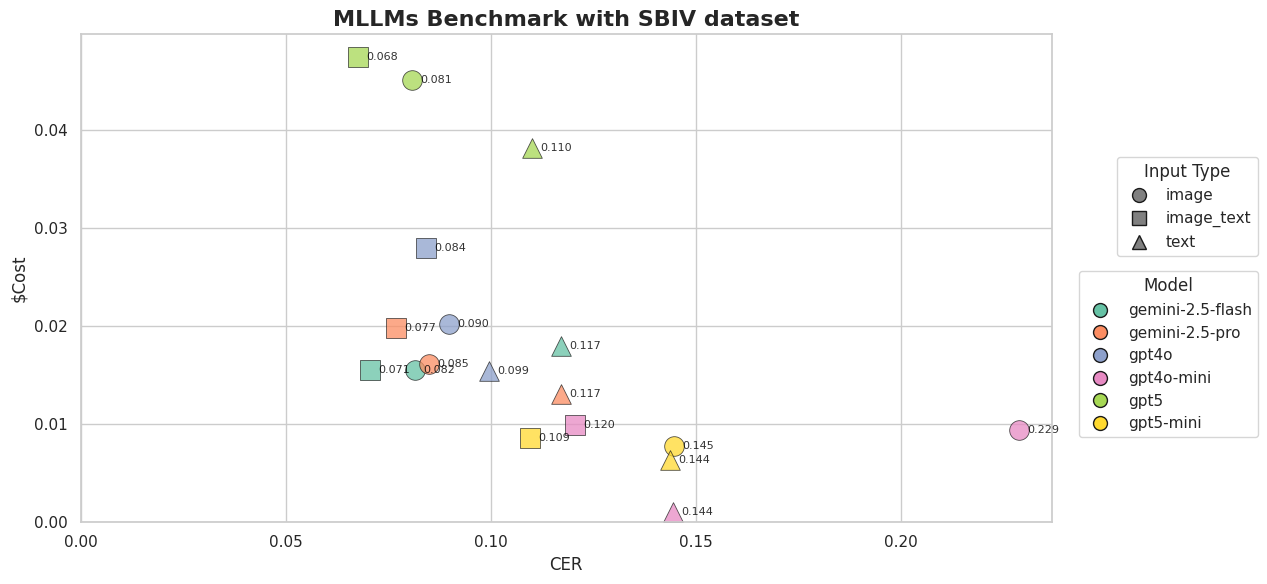

Đã lưu hình scatter có nhãn CER cạnh điểm tại: MLLMs_Benchmark_SBIV.png


In [ ]:
import glob, os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D

# --- Helper: tìm tên cột bất kể hoa/thường ---
def find_col(df, target):
    target_low = target.lower()
    for c in df.columns:
        if c.lower() == target_low:
            return c
    for c in df.columns:
        if target_low in c.lower():
            return c
    return None

# --- Load và gộp các file Benchmark ---
os.makedirs("/content/benchmark", exist_ok=True)
files = sorted(glob.glob("/content/benchmark/Benchmark_*.csv"))
# print("files : ", files)
dfs = []
for f in files:
    # print(f)
    df = pd.read_csv(f)
    # display(df)
    basename = os.path.basename(f)
    model = basename.split("_")[1]
    col_cost = find_col(df, "average_cost")
    # col_latency = find_col(df, "p99_latency")
    col_cer = find_col(df, "cer")
    col_input = find_col(df, "input_type")
    # df = df[[col_input, col_cost, col_latency, col_cer]].copy()
    # df.columns = ["input_type", "average_cost", "p99_latency", "cer"]

    df = df[[col_input, col_cost, col_cer]].copy()
    df.columns = ["input_type", "average_cost", "cer"]

    df["model"] = model
    dfs.append(df)

df_all = pd.concat(dfs, ignore_index=True)

# Lấy trung bình theo model + input_type
group = df_all.groupby(["model", "input_type"], as_index=False).mean()

# --- Mapping input_type sang hình khối ---
unique_inputs = sorted(group["input_type"].unique())
marker_map = {inp: m for inp, m in zip(unique_inputs, ["o", "s", "^", "D", "P", "X"])}

# --- Scale kích thước theo latency ---
# lat_min, lat_max = group["p99_latency"].min(), group["p99_latency"].max()
# if lat_max == lat_min:
#     group["size"] = 300
# else:
#     group["size"] = 100 + (group["p99_latency"] - lat_min) / (lat_max - lat_min) * 1000

# --- Plot ---
sns.set_theme(style="whitegrid")
plt.figure(figsize=(17, 6))

palette = sns.color_palette("Set2", len(group["model"].unique()))
color_map = {m: palette[i] for i, m in enumerate(sorted(group["model"].unique()))}

# Vẽ từng điểm + nhãn CER
for _, row in group.iterrows():
    plt.scatter(row["cer"], row["average_cost"],
                s=200,
                marker=marker_map[row["input_type"]],
                color=color_map[row["model"]],
                alpha=0.75,
                edgecolor="k",
                linewidth=0.6)

    # Nhãn CER hiển thị bên phải điểm
    plt.text(row["cer"] + 0.002, row["average_cost"],   # dịch nhẹ sang phải
             f"{row['cer']:.3f}",
             fontsize=8, ha="left", va="center",
             color="black", alpha=0.8)

# --- Legends ---
# Model (màu)
model_handles = [Line2D([0], [0], marker="o", color="w",
                        markerfacecolor=color_map[m], markersize=10,
                        markeredgecolor="k", label=m)
                 for m in sorted(group["model"].unique())]

# Input type (hình khối)
input_handles = [Line2D([0], [0], marker=marker_map[inp], color="w",
                        markerfacecolor="gray", markersize=10,
                        markeredgecolor="k", label=inp)
                 for inp in unique_inputs]

# Latency (kích thước)
# size_vals = np.linspace(lat_min, lat_max, 3)
# size_areas = 100 + (size_vals - lat_min) / (lat_max - lat_min) * 1000 if lat_max!=lat_min else [300, 300, 300]
# size_handles = [plt.scatter([], [], s=a, color="gray", alpha=0.6, edgecolor="k") for a in size_areas]
# size_labels = [f"{v:.1f}" for v in size_vals]

# Thêm legend
leg1 = plt.legend(handles=model_handles, title="Model", loc="upper right", bbox_to_anchor=(1.22, 0.53))
plt.legend(handles=input_handles, title="Input Type", loc="lower right", bbox_to_anchor=(1.22, 0.53))
# plt.legend(handles=size_handles, labels=size_labels, title="P99 Latency (ms)", loc="lower right", bbox_to_anchor=(1.22, 0.1))

plt.gca().add_artist(leg1)
# plt.gca().add_artist(leg2)

plt.xlabel("CER")
plt.ylabel("$Cost")
plt.title("MLLMs Benchmark with SBIV dataset",
          fontsize=16, fontweight="bold")

# --- Chỉnh trục bắt đầu từ 0 ---
plt.xlim(left=0)
plt.ylim(bottom=0)
plt.tight_layout(rect=[0, 0, 0.8, 1])
# plt.figure(constrained_layout=True)
out_path = "MLLMs_Benchmark_SBIV.png"
plt.savefig(out_path, dpi=250, bbox_inches="tight")
plt.show()

print(f"Đã lưu hình scatter có nhãn CER cạnh điểm tại: {out_path}")
